# Hyperbolic Embedding of Graphs

In [17]:
import logging
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np 

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.geometry.poincare_ball import PoincareBall

In [18]:
gs.random.seed(1234)
dim = 3
max_epochs = 1000
lr = 1e-2
n_negative = 2
context_size = 1

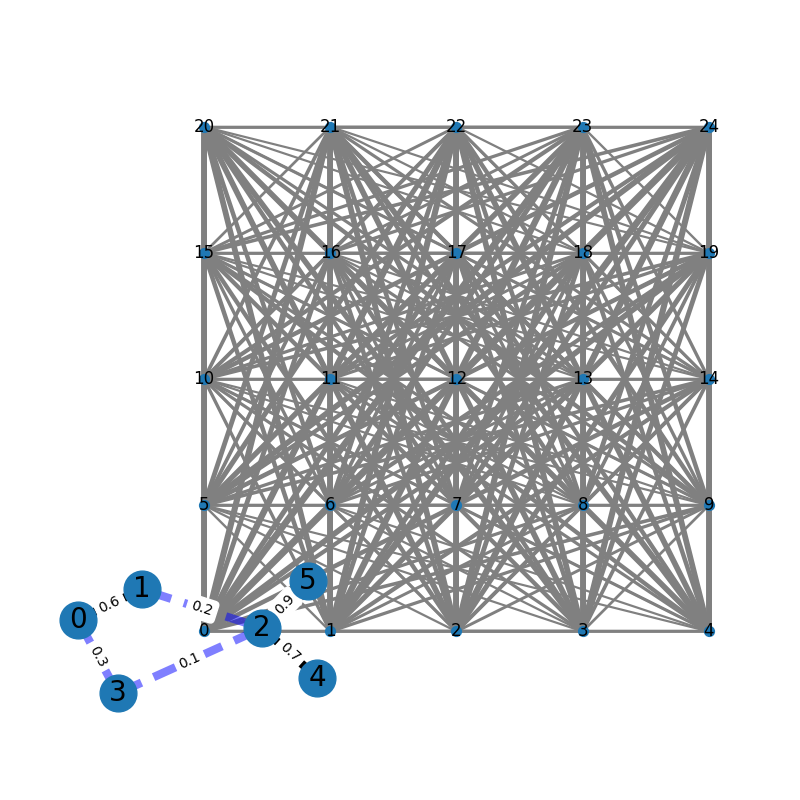

In [19]:
graph = nx.Graph()

graph.add_edge(0, 1, weight=0.6)
graph.add_edge(1, 2, weight=0.2)
graph.add_edge(2, 3, weight=0.1)
graph.add_edge(2, 4, weight=0.7)
graph.add_edge(2, 5, weight=0.9)
graph.add_edge(0, 3, weight=0.3)

elarge = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] > 0.5]
esmall = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] <= 0.5]

pos = nx.spring_layout(graph, seed=7)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(graph, pos, node_size=700)

# edges
nx.draw_networkx_edges(graph, pos, edgelist=elarge, width=6)
nx.draw_networkx_edges(
    graph, pos, edgelist=esmall, width=6, alpha=0.5, edge_color="b", style="dashed"
)

# node labels
nx.draw_networkx_labels(graph, pos, font_size=20, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(graph, "weight")
nx.draw_networkx_edge_labels(graph, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

44.5
50.0
56.5
64.0
58.0
62.5
68.0
74.5
82.0
80.0
84.5
90.0
96.5
104.0
106.0
110.5
116.0
122.5
130.0
136.0
140.5
146.0
152.5
160.0
44.5
50.0
56.5
54.5
58.0
62.5
68.0
74.5
76.5
80.0
84.5
90.0
96.5
102.5
106.0
110.5
116.0
122.5
132.5
136.0
140.5
146.0
152.5
44.5
50.0
52.0
54.5
58.0
62.5
68.0
74.0
76.5
80.0
84.5
90.0
100.0
102.5
106.0
110.5
116.0
130.0
132.5
136.0
140.5
146.0
44.5
50.5
52.0
54.5
58.0
62.5
72.5
74.0
76.5
80.0
84.5
98.5
100.0
102.5
106.0
110.5
128.5
130.0
132.5
136.0
140.5
50.0
50.5
52.0
54.5
58.0
72.0
72.5
74.0
76.5
80.0
98.0
98.5
100.0
102.5
106.0
128.0
128.5
130.0
132.5
136.0
44.5
50.0
56.5
64.0
58.0
62.5
68.0
74.5
82.0
80.0
84.5
90.0
96.5
104.0
106.0
110.5
116.0
122.5
130.0
44.5
50.0
56.5
54.5
58.0
62.5
68.0
74.5
76.5
80.0
84.5
90.0
96.5
102.5
106.0
110.5
116.0
122.5
44.5
50.0
52.0
54.5
58.0
62.5
68.0
74.0
76.5
80.0
84.5
90.0
100.0
102.5
106.0
110.5
116.0
44.5
50.5
52.0
54.5
58.0
62.5
72.5
74.0
76.5
80.0
84.5
98.5
100.0
102.5
106.0
110.5
50.0
50.5
52.0
54.5
58.0
72.0
72

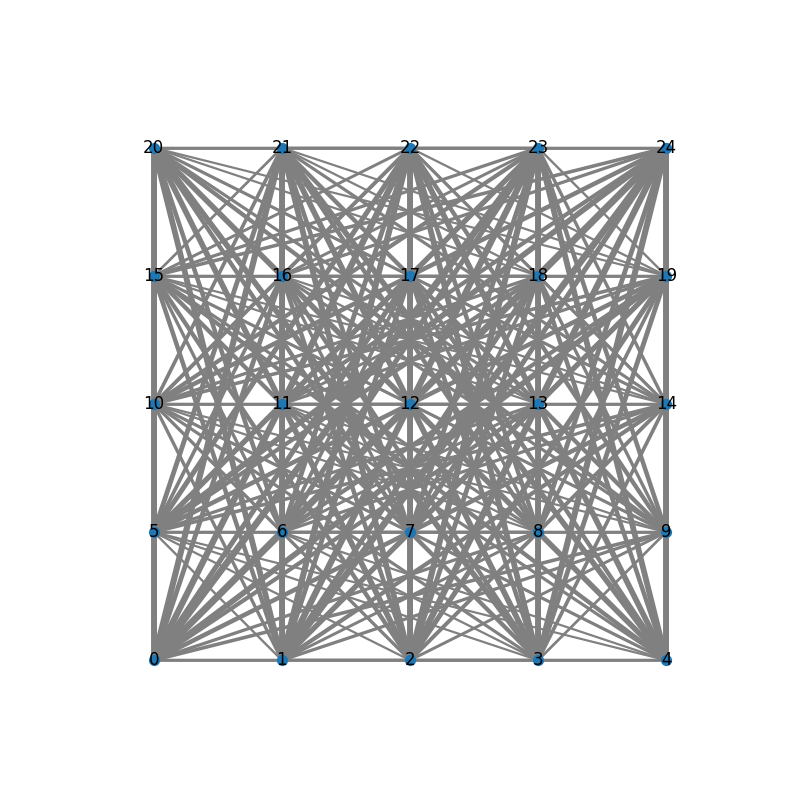

In [20]:
# Create a graph of a 2D grid with a pairwise function defined for weights.
from sklearn.metrics.pairwise import rbf_kernel

grid_size = (5, 5)
x_vals = np.linspace(0, 4, grid_size[0])
y_vals = np.linspace(0, 4, grid_size[1])
X1, X2 = np.meshgrid(x_vals, y_vals)
points = np.column_stack([X1.ravel(), X2.ravel()])

# Function for edge weights
def f(x, y, w, c):
    err = (x-y-2*c)**2 
    val = np.dot(np.asarray(w), err)

    return val

# Step 3: Build a weighted graph
graph = nx.Graph()
for i, xi in enumerate(points):
    graph.add_node(i, pos=tuple(xi))

# Add edges with weights
for i in range(len(points)):
    for j in range(i + 1, len(points)):
        weight = f(points[i,:], points[j,:], [0.5, 2.0], np.asarray([2.0, 2.0]))
        print(weight)
        graph.add_edge(i, j, weight=weight.item()/100.0)

# Step 4: Visualize
pos = nx.get_node_attributes(graph, 'pos')
weights = np.array([graph[u][v]['weight'] for u, v in graph.edges()])
norm_weights = 5 * (weights / weights.max())  # Scale for linewidths

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw(graph, pos,
        node_size=50,
        edge_color='gray',
        width=norm_weights,
        with_labels=True,
        ax = ax)
ax.axis('equal')
plt.show()


In [21]:
nb_vertices_by_edges = [len(e_2) for _, e_2 in graph.edges.items()]
logging.info("Number of vertices: %s", len(graph.edges))
logging.info(
    "Mean edge-vertex ratio: %s",
    (sum(nb_vertices_by_edges, 0) / len(graph.edges)),
)

INFO: Number of vertices: 300
INFO: Mean edge-vertex ratio: 1.0


Declaring an instance of the `PoincareBall` manifold of $d$ dimensions in `geomstats` is straightforward:

In [22]:
hyperbolic_manifold = PoincareBall(dim)

## Loss function.

To preserve first and second-order proximities we adopt a loss function similar to (Nickel, 2017) and consider the negative sampling approach as in (Mikolov, 2013) :

$$     \mathcal{L} = - \sum_{v_i\in V} \sum_{v_j \in C_i} \bigg[ log(\sigma(-w_{ij}d^2(\phi_i, \phi_j'))) + \sum_{v_k\sim \mathcal{P}_n} log(\sigma(w_{ik}d^2(\phi_i, \phi_k')))  \bigg]$$

where $\sigma(x)=\frac{1}{1+e^{-x}}$ is the sigmoid function and $\phi_i \in \mathbb{B}^m$ 
is the embedding of the $i$-th node of $V$, $C_i$ the nodes in the context of the 
$i$-th node, $\phi_j'\in \mathbb{B}^m$ the embedding of $v_j\in C_i$ and 
$\mathcal{P}_n$ the negative sampling distribution over $V$: 
$$ \mathcal{P}_n(v)=\frac{deg(v)^{3/4}}{\sum_{v_i\in V}deg(v_i)^{3/4}} $$ 

Intuitively one can see that to minimizing $L$, the distance between $v_i$ and $v_j$ should get smaller, while the one between
$v_i$ and $v_k$ would get larger.

In [23]:
def grad_squared_distance(manifold, point_a, point_b):
    """Gradient of squared hyperbolic distance.

    Gradient of the squared distance based on the
    Ball representation according to point_a

    Parameters
    ----------
    point_a : array-like, shape=[n_samples, dim]
        First point in hyperbolic space.
    point_b : array-like, shape=[n_samples, dim]
        Second point in hyperbolic space.

    Returns
    -------
    dist : array-like, shape=[n_samples, 1]
        Geodesic squared distance between the two points.
    """
    log_map = manifold.metric.log(point_b, point_a)

    return -2 * log_map

For 2. define the `log_sigmoid` corresponding as follows:

In [24]:
def log_sigmoid(vector):
    """Logsigmoid function.

    Apply log sigmoid function

    Parameters
    ----------
    vector : array-like, shape=[n_samples, dim]

    Returns
    -------
    result : array-like, shape=[n_samples, dim]
    """
    return gs.log((1 / (1 + gs.exp(-vector))))

The gradient of the logarithm of sigmoid function is implemented as:

In [25]:
def grad_log_sigmoid(vector):
    """Gradient of log sigmoid function.

    Parameters
    ----------
    vector : array-like, shape=[n_samples, dim]

    Returns
    -------
    gradient : array-like, shape=[n_samples, dim]
    """
    return 1 / (1 + gs.exp(vector))

In [26]:
def loss(example_embedding, context_embedding, negative_embedding, w_ij, w_ik, manifold):
    """Compute loss and grad.

    Compute loss and grad given embedding of the current example,
    embedding of the context and negative sampling embedding.
    """
    n_edges, dim = negative_embedding.shape[0], example_embedding.shape[-1]
    example_embedding = gs.expand_dims(example_embedding, 0)
    context_embedding = gs.expand_dims(context_embedding, 0)

    # loss T1
    positive_distance = manifold.metric.squared_dist(
        example_embedding, context_embedding
    )
    positive_loss = log_sigmoid(-gs.array(w_ij)*positive_distance)

    # loss T2
    reshaped_example_embedding = gs.repeat(example_embedding, n_edges, axis=0)
    negative_distance = manifold.metric.squared_dist(
        reshaped_example_embedding, negative_embedding
    )
    negative_loss = log_sigmoid(gs.array(w_ik)*negative_distance)

    total_loss = -(positive_loss + negative_loss.sum())

    # grad loss T1
    positive_log_sigmoid_grad = -grad_log_sigmoid(-positive_distance)
    positive_distance_grad = grad_squared_distance(
        manifold, example_embedding, context_embedding
    )
    positive_grad = (
        gs.repeat(positive_log_sigmoid_grad, dim, 
                  axis=-1) * (gs.array(w_ij)*positive_distance_grad)
    )

    # grad loss T2
    negative_distance_grad = grad_squared_distance(
        manifold, reshaped_example_embedding,negative_embedding
    )
    negative_distance = gs.to_ndarray(negative_distance, to_ndim=2, axis=-1)
    negative_log_sigmoid_grad = grad_log_sigmoid(negative_distance)

    negative_grad = (
        gs.repeat(negative_log_sigmoid_grad, dim, 
                  axis=-1) * gs.einsum('i,ij->ij', gs.array(w_ik), negative_distance_grad)
    )

    example_grad = -(positive_grad + negative_grad.sum(axis=0))

    return total_loss, example_grad

In [27]:
embeddings = gs.random.normal(size=(graph.number_of_nodes(), dim))
embeddings = embeddings * 0.2

In [28]:
random_walks = list(nx.generate_random_paths(graph, sample_size=3, path_length=4, seed=42))

Negatively sampled nodes $v_k$ are chosen according to the previously defined probability distribution function
$\mathcal{P}_n(v_k)$ implemented as

In [29]:
negative_table_parameter = 5
negative_sampling_table = []

for i, d in graph.degree(weight='weight'):
    negative_sampling_table += (
        [i] * int((d ** (3.0 / 4.0))) * negative_table_parameter
    )

negative_sampling_table = gs.array(negative_sampling_table)

In [30]:
for epoch in range(max_epochs):
    total_loss = []
    for path in random_walks:
        for example_index, i in enumerate(path):
            context_index = path[
                max(0, example_index - context_size) : min(
                    example_index + context_size, len(path)
                )
            ]
            negative_index = gs.random.randint(
                negative_sampling_table.shape[0], size=(len(context_index), n_negative)
            )
            negative_index = negative_sampling_table[negative_index]

            phi_i = embeddings[i]
            for j, k in zip(context_index, negative_index):
                phi_jp = embeddings[j]
                phi_kp = embeddings[k]
                w_ij = graph[i][j]['weight'] if graph.has_edge(i, j) else 1.0
                w_ik = []
                for kn in k:
                    if graph.has_edge(i, kn):
                        w_ik.append(graph[i][kn]['weight'])
                    else:
                        w_ik.append(1.0)
                total_loss_, g_ex = loss(
                    phi_i,
                    phi_jp,
                    phi_kp,
                    w_ij,
                    w_ik,
                    hyperbolic_manifold,
                )
                total_loss.append(total_loss_)

                example_to_update = embeddings[i]
                embeddings[i] = hyperbolic_manifold.metric.exp(
                    -lr * g_ex, example_to_update
                )
    logging.info(
        "iteration %d loss_value %f", epoch, sum(total_loss, 0) / len(total_loss)
    )

INFO: iteration 0 loss_value 1.913454
INFO: iteration 1 loss_value 1.944235
INFO: iteration 2 loss_value 1.835558
INFO: iteration 3 loss_value 1.886895
INFO: iteration 4 loss_value 1.857976
INFO: iteration 5 loss_value 1.876530
INFO: iteration 6 loss_value 1.806510
INFO: iteration 7 loss_value 1.762939
INFO: iteration 8 loss_value 1.810991
INFO: iteration 9 loss_value 1.756091
INFO: iteration 10 loss_value 1.769269
INFO: iteration 11 loss_value 1.749225
INFO: iteration 12 loss_value 1.770179
INFO: iteration 13 loss_value 1.850018
INFO: iteration 14 loss_value 1.689182
INFO: iteration 15 loss_value 1.699616
INFO: iteration 16 loss_value 1.654201
INFO: iteration 17 loss_value 1.667673
INFO: iteration 18 loss_value 1.703700
INFO: iteration 19 loss_value 1.784543
INFO: iteration 20 loss_value 1.712488
INFO: iteration 21 loss_value 1.681747
INFO: iteration 22 loss_value 1.707956
INFO: iteration 23 loss_value 1.631378
INFO: iteration 24 loss_value 1.637107
INFO: iteration 25 loss_value 1.664

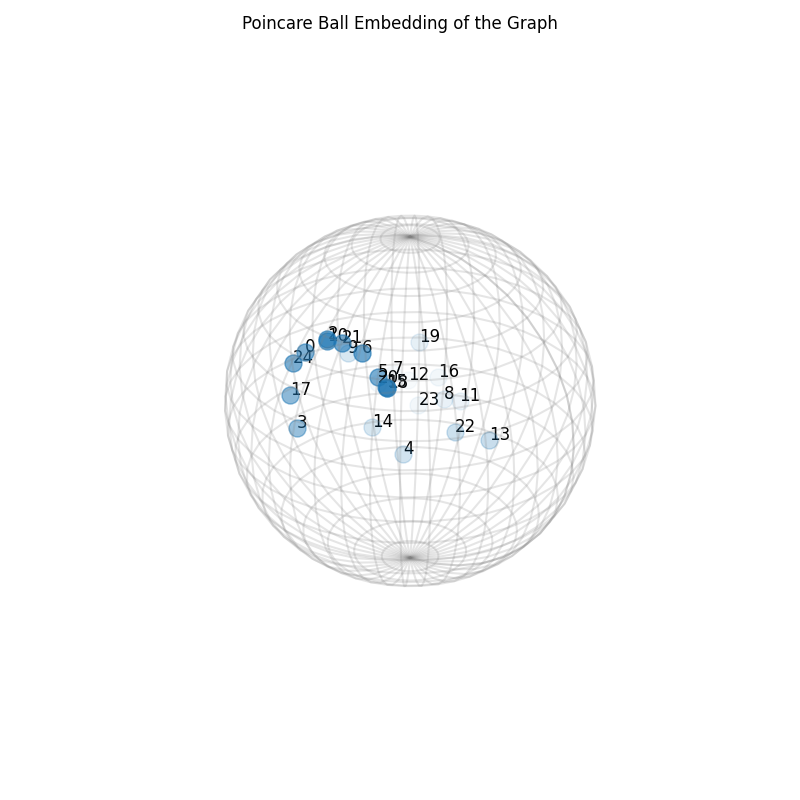

In [31]:
%matplotlib widget

from geomstats.visualization.hypersphere import Sphere 

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection" : "3d"})
sph = Sphere()
sph.set_ax(ax) 
sph.draw(ax)

for i, embedding in enumerate(embeddings):
    x = embedding[0]
    y = embedding[1]
    z = embedding[2]
    ax.scatter(x, y, z, s=150, color= "tab:blue", alpha=(np.asarray([x,y,z])**2).sum().item())
    ax.text(x, y, z, str(i), color='black', fontsize=12)

ax.axis("off")
ax.set_title("Poincare Ball Embedding of the Graph")
plt.tight_layout()
plt.show()